[GitHub Repository](https://github.com/UGESHDHUNGEL/AI-assignment-.git)

In [15]:
import pandas as pd

df = pd.read_csv('Human_Development_Index_Dataset.csv', encoding='latin1')
print(f"Data loaded. Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Data loaded. Shape: (6798, 30)
Columns: ['Unnamed: 0', 'iso3', 'country', 'year', 'hdi', 'life_expectancy', 'pop_millions', 'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m', 'expec_yr_school', 'expec_yr_school_f', 'expec_yr_school_m', 'mean_yr_school', 'mean_yr_school_f', 'mean_yr_school_m', 'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m', 'gender_development', 'gender_inequality', 'secondary_education_f_%', 'secondary_education_m_%', 'seats_in_parliament_f_%', 'seats_in_parliament_m_%', 'labour_participation_f_%', 'labour_participation_m_%', 'co2_emission_tons', 'mat_footprint_percap_tons']


3.1	Problem - 1A - Single Year HDI Exploration (Latest Year: 2022)

1.	Extract Latest Year

In [19]:
# Check what years are available
unique_years = df['year'].unique()
print(f"Years in dataset: {sorted(unique_years)}")
print(f"Latest year: {max(unique_years)}")

# Filter for 2022
hdi_2022_df = df[df['year'] == 2022].copy()
print(f"\n2022 data shape: {hdi_2022_df.shape}")
print(f"Number of countries in 2022: {hdi_2022_df['country'].nunique()}")

Years in dataset: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Latest year: 2022

2022 data shape: (206, 30)
Number of countries in 2022: 206


 2. Data Expolation

In [21]:
# Display first 10 rows of 2022 data
print("First 10 rows of 2022 dataset:")
print(hdi_2022_df.head(10))

# Count rows and columns
print(f"\nNumber of rows: {hdi_2022_df.shape[0]}")
print(f"Number of columns: {hdi_2022_df.shape[1]}")

# List column names and data types
print("\nColumn names and data types:")
for col in hdi_2022_df.columns:
    print(f"  {col}: {hdi_2022_df[col].dtype}")

First 10 rows of 2022 dataset:
     Unnamed: 0 iso3              country  year    hdi  life_expectancy  \
32           33  AFG          Afghanistan  2022  0.462           62.879   
65           66  ALB              Albania  2022  0.789           76.833   
98           99  DZA              Algeria  2022  0.745           77.129   
131         132  AND              Andorra  2022  0.884           83.552   
164         165  AGO               Angola  2022  0.591           61.929   
197         198  ATG  Antigua and Barbuda  2022  0.826           79.236   
230         231  ARG            Argentina  2022  0.849           76.064   
263         264  ARM              Armenia  2022  0.786           73.372   
296         297  AUS            Australia  2022  0.946           83.579   
329         330  AUT              Austria  2022  0.926           82.412   

     pop_millions     hdi_f     hdi_m  life_expec_f  ...  gender_development  \
32      41.128771  0.332443  0.534145        66.213  ...       

3.	Missing Values & Data Cleaning:

In [23]:
import numpy as np

# 1. Check for missing values
print("Missing values in each column:")
missing_counts = hdi_2022_df.isnull().sum()
print(missing_counts[missing_counts > 0])

# 2. Check for duplicate rows
duplicate_rows = hdi_2022_df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

# 3. Check for special characters in numeric columns
print("\nChecking for special characters in numeric columns...")
numeric_columns = hdi_2022_df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if hdi_2022_df[col].dtype == 'object':  # If numeric column is stored as text
        print(f"Column '{col}' is stored as text")

# 4. Check country names (first 20 unique)
print("\nFirst 20 unique country names:")
print(hdi_2022_df['country'].unique()[:20])

Missing values in each column:
hdi                           2
hdi_f                        13
hdi_m                        13
expec_yr_school               1
expec_yr_school_f             1
expec_yr_school_m             1
mean_yr_school                2
mean_yr_school_f              2
mean_yr_school_m              2
gross_inc_percap              2
gross_inc_percap_f           13
gross_inc_percap_m           13
gender_development           13
gender_inequality            29
secondary_education_f_%      17
secondary_education_m_%      17
seats_in_parliament_f_%       2
seats_in_parliament_m_%       2
labour_participation_f_%     12
labour_participation_m_%     12
co2_emission_tons             2
mat_footprint_percap_tons    41
dtype: int64

Number of duplicate rows: 0

Checking for special characters in numeric columns...

First 20 unique country names:
['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' '

4.	Basic Statistics:

In [25]:
# Make sure HDI column is numeric
hdi_2022_df['hdi'] = pd.to_numeric(hdi_2022_df['hdi'], errors='coerce')

# 1. Compute basic statistics
hdi_mean = hdi_2022_df['hdi'].mean()
hdi_median = hdi_2022_df['hdi'].median()
hdi_std = hdi_2022_df['hdi'].std()

print(f"HDI Statistics for 2022:")
print(f"  Mean: {hdi_mean:.3f}")
print(f"  Median: {hdi_median:.3f}")
print(f"  Standard Deviation: {hdi_std:.3f}")

# 2. Country with highest HDI
highest_hdi = hdi_2022_df.loc[hdi_2022_df['hdi'].idxmax()]
print(f"\nCountry with highest HDI:")
print(f"  Country: {highest_hdi['country']}")
print(f"  HDI: {highest_hdi['hdi']:.3f}")

# 3. Country with lowest HDI
lowest_hdi = hdi_2022_df.loc[hdi_2022_df['hdi'].idxmin()]
print(f"\nCountry with lowest HDI:")
print(f"  Country: {lowest_hdi['country']}")
print(f"  HDI: {lowest_hdi['hdi']:.3f}")

HDI Statistics for 2022:
  Mean: 0.723
  Median: 0.740
  Standard Deviation: 0.153

Country with highest HDI:
  Country: Switzerland
  HDI: 0.967

Country with lowest HDI:
  Country: Somalia
  HDI: 0.380


5. filtering and sorting

In [27]:
# First check if the GNI column exists with correct name
print("Available columns:")
print(hdi_2022_df.columns.tolist())

# Try different possible column names for GNI
gni_column = None
possible_names = ['gross_inc_percap', 'gross inc percap', 'gni_per_capita', 'gni', 'income']
for name in possible_names:
    if name in hdi_2022_df.columns:
        gni_column = name
        break

if gni_column:
    # 1. Filter countries with HDI > 0.800
    high_hdi_countries = hdi_2022_df[hdi_2022_df['hdi'] > 0.800].copy()
    print(f"\nNumber of countries with HDI > 0.800: {len(high_hdi_countries)}")
    
    # 2. Sort by GNI per capita (descending)
    high_hdi_sorted = high_hdi_countries.sort_values(gni_column, ascending=False)
    
    # 3. Display top 10 countries
    print("\nTop 10 countries with HDI > 0.800 (sorted by GNI per capita):")
    print(high_hdi_sorted[['country', 'hdi', gni_column]].head(10).to_string(index=False))
    
else:
    print("\nERROR: GNI column not found. Available columns are above.")
    print("Showing top countries by HDI > 0.800 instead:")
    high_hdi = hdi_2022_df[hdi_2022_df['hdi'] > 0.800].sort_values('hdi', ascending=False)
    print(high_hdi[['country', 'hdi']].head(10).to_string(index=False))

Available columns:
['Unnamed: 0', 'iso3', 'country', 'year', 'hdi', 'life_expectancy', 'pop_millions', 'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m', 'expec_yr_school', 'expec_yr_school_f', 'expec_yr_school_m', 'mean_yr_school', 'mean_yr_school_f', 'mean_yr_school_m', 'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m', 'gender_development', 'gender_inequality', 'secondary_education_f_%', 'secondary_education_m_%', 'seats_in_parliament_f_%', 'seats_in_parliament_m_%', 'labour_participation_f_%', 'labour_participation_m_%', 'co2_emission_tons', 'mat_footprint_percap_tons']

Number of countries with HDI > 0.800: 71

Top 10 countries with HDI > 0.800 (sorted by GNI per capita):
               country   hdi  gross_inc_percap
         Liechtenstein 0.942      146673.24150
                 Qatar 0.875       95944.37754
             Singapore 0.949       88761.14559
               Ireland 0.950       87467.51391
            Luxembourg 0.927       78554.23640
  United Arab Emirat

6.	Adding HDI Category Column:

In [29]:
# Define function to categorize HDI
def categorize_hdi(hdi_value):
    if pd.isna(hdi_value):
        return 'Unknown'
    elif hdi_value < 0.550:
        return 'Low'
    elif hdi_value < 0.700:  # 0.550 to 0.699
        return 'Medium'
    elif hdi_value < 0.800:  # 0.700 to 0.799
        return 'High'
    else:  # 0.800 and above
        return 'Very High'

# Apply the categorization
hdi_2022_df['HDI_Category'] = hdi_2022_df['hdi'].apply(categorize_hdi)

# 1. Verify all countries are classified correctly
print("HDI Category Distribution:")
category_counts = hdi_2022_df['HDI_Category'].value_counts()
print(category_counts)

# Show sample from each category
print("\nSample countries from each category:")
for category in ['Very High', 'High', 'Medium', 'Low', 'Unknown']:
    if category in hdi_2022_df['HDI_Category'].values:
        sample_countries = hdi_2022_df[hdi_2022_df['HDI_Category'] == category][['country', 'hdi']].head(3)
        print(f"\n{category} HDI (n={category_counts.get(category, 0)}):")
        print(sample_countries.to_string(index=False))

# 2. Ensure updated dataframe has the new column
print(f"\nUpdated dataframe columns:")
print(hdi_2022_df.columns.tolist())

# 3. Save to CSV
hdi_2022_df.to_csv('HDI_category_added.csv', index=False)
print("\nData saved to 'HDI_category_added.csv'")
print(f"File contains {len(hdi_2022_df)} rows and {len(hdi_2022_df.columns)} columns")

HDI Category Distribution:
HDI_Category
Very High    71
High         54
Medium       44
Low          35
Unknown       2
Name: count, dtype: int64

Sample countries from each category:

Very High HDI (n=71):
            country   hdi
            Andorra 0.884
Antigua and Barbuda 0.826
          Argentina 0.849

High HDI (n=54):
country   hdi
Albania 0.789
Algeria 0.745
Armenia 0.786

Medium HDI (n=44):
   country   hdi
    Angola 0.591
Bangladesh 0.670
    Bhutan 0.681

Low HDI (n=35):
     country   hdi
 Afghanistan 0.462
       Benin 0.504
Burkina Faso 0.438

Unknown HDI (n=2):
                            country  hdi
Korea (Democratic People's Rep. of)  NaN
                             Monaco  NaN

Updated dataframe columns:
['Unnamed: 0', 'iso3', 'country', 'year', 'hdi', 'life_expectancy', 'pop_millions', 'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m', 'expec_yr_school', 'expec_yr_school_f', 'expec_yr_school_m', 'mean_yr_school', 'mean_yr_school_f', 'mean_yr_school_m', 'gross_inc



3.2	Problem - 1B
- HDI Visualization and Trend Analysis (2020 – 2022)
Objective:
Analyze multi-year HDI patterns (2020, 2021, and 2022) to explore temporal changes, regional differences, and trends across countries.


Task :

1.Data Extraction and Saving:

In [33]:
# Filter dataset for years 2020, 2021, and 2022
years_to_keep = [2020, 2021, 2022]
hdi_2020_2022_df = df[df['year'].isin(years_to_keep)].copy()

print(f"Original dataset shape: {df.shape}")
print(f"Filtered dataset shape (2020-2022): {hdi_2020_2022_df.shape}")
print(f"\nYears in filtered dataset: {sorted(hdi_2020_2022_df['year'].unique())}")

# Save to CSV
hdi_2020_2022_df.to_csv('HDI_problem1B.csv', index=False)
print(f"\nSaved to 'HDI_problem1B.csv'")
print(f"File contains data from {len(hdi_2020_2022_df)} rows")

Original dataset shape: (6798, 30)
Filtered dataset shape (2020-2022): (618, 30)

Years in filtered dataset: [2020, 2021, 2022]

Saved to 'HDI_problem1B.csv'
File contains data from 618 rows


 2.Data cleaning 

In [35]:
# Load the filtered dataset
hdi_problem1b = pd.read_csv('HDI_problem1B.csv')


# 1. Check missing values in essential columns
print("\n1. Missing values in essential columns:")
essential_cols = ['hdi', 'country', 'year']
for col in essential_cols:
    if col in hdi_problem1b.columns:
        missing = hdi_problem1b[col].isnull().sum()
        print(f"   {col}: {missing} missing ({missing/len(hdi_problem1b)*100:.1f}%)")
    else:
        print(f"   {col}: COLUMN NOT FOUND")

# 2. Check for duplicate rows
print(f"\n2. Duplicate rows: {hdi_problem1b.duplicated().sum()}")

# 3. Check data types
print("\n3. Data types of key columns:")
for col in essential_cols:
    if col in hdi_problem1b.columns:
        print(f"   {col}: {hdi_problem1b[col].dtype}")

# 4. Check for non-numeric values in HDI column
print("\n4. Checking HDI column for non-numeric values...")
if 'hdi' in hdi_problem1b.columns:
    # Try to convert to numeric
    hdi_numeric = pd.to_numeric(hdi_problem1b['hdi'], errors='coerce')
    non_numeric_count = hdi_numeric.isnull().sum() - hdi_problem1b['hdi'].isnull().sum()
    print(f"   Non-numeric values found in HDI: {non_numeric_count}")
    
    # Show sample of problematic rows if any
    if non_numeric_count > 0:
        problematic = hdi_problem1b[pd.to_numeric(hdi_problem1b['hdi'], errors='coerce').isna()]
        print(f"   Sample problematic rows:")
        print(problemable[['country', 'year', 'hdi']].head())


1. Missing values in essential columns:
   hdi: 8 missing (1.3%)
   country: 0 missing (0.0%)
   year: 0 missing (0.0%)

2. Duplicate rows: 0

3. Data types of key columns:
   hdi: float64
   country: object
   year: int64

4. Checking HDI column for non-numeric values...
   Non-numeric values found in HDI: 0


3.	Visualization Tasks:

File saved successfully as HDI_problem1B.csv


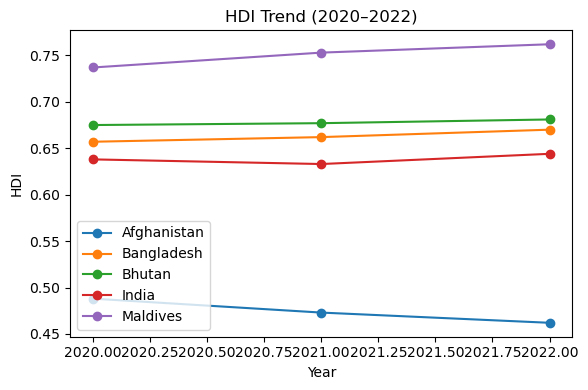

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset and select years
df = pd.read_csv("Human_Development_Index_Dataset.csv", encoding="latin1")

selected_years = [2020, 2021, 2022]
hdi_df = df[df["year"].isin(selected_years)].copy()


# Clean the data
num_columns = ["hdi", "life_expectancy", "gross_inc_percap", "gender_development"]
hdi_df[num_columns] = hdi_df[num_columns].apply(pd.to_numeric, errors="coerce")

hdi_df.drop_duplicates(inplace=True)
hdi_df.dropna(subset=["hdi", "country", "year"], inplace=True)

# Save cleaned file (Spyder-safe)
output_file = "HDI_problem1B.csv"
hdi_df.to_csv(output_file, index=False)
print(f"File saved successfully as {output_file}")

# Add region information
region_map = {
    "Afghanistan": "South Asia", "Bangladesh": "South Asia", "Bhutan": "South Asia",
    "India": "South Asia", "Maldives": "South Asia", "Nepal": "South Asia",
    "Pakistan": "South Asia", "Sri Lanka": "South Asia",
    "Bahrain": "Middle East", "Iran": "Middle East", "Iraq": "Middle East",
    "Israel": "Middle East", "Jordan": "Middle East", "Kuwait": "Middle East",
    "Lebanon": "Middle East", "Oman": "Middle East", "Palestine": "Middle East",
    "Qatar": "Middle East", "Saudi Arabia": "Middle East", "Syria": "Middle East",
    "United Arab Emirates": "Middle East", "Yemen": "Middle East"
}

hdi_df["region"] = hdi_df["country"].map(region_map)

south_asia = (
    hdi_df[hdi_df["region"] == "South Asia"]["country"]
    .dropna()
    .unique()[:5]
)

plt.figure(figsize=(6, 4))
for country in south_asia:
    data = hdi_df[hdi_df["country"] == country]
    plt.plot(data["year"], data["hdi"], marker="o", label=country)

plt.title("HDI Trend (2020–2022)")
plt.xlabel("Year")
plt.ylabel("HDI")
plt.legend()
plt.tight_layout()
plt.show()


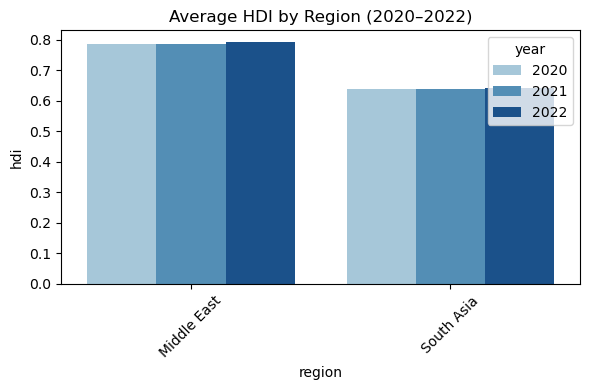

In [56]:
region_avg = (
    hdi_df.groupby(["region", "year"])["hdi"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=region_avg,
    x="region",
    y="hdi",
    hue="year",
    palette=["#9ecae1", "#4292c6", "#08519c"]
)

plt.title("Average HDI by Region (2020–2022)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


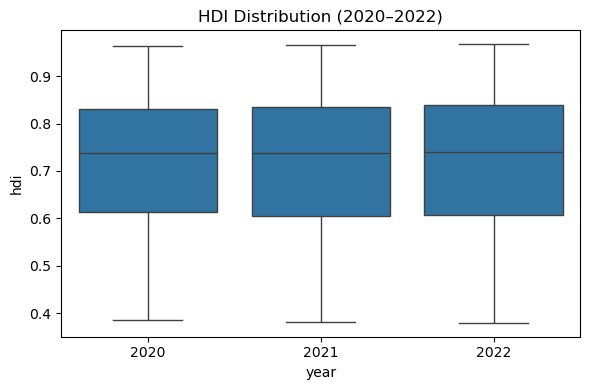

In [50]:

plt.figure(figsize=(6, 4))
sns.boxplot(data=hdi_df, x="year", y="hdi")
plt.title("HDI Distribution (2020–2022)")
plt.tight_layout()
plt.show()


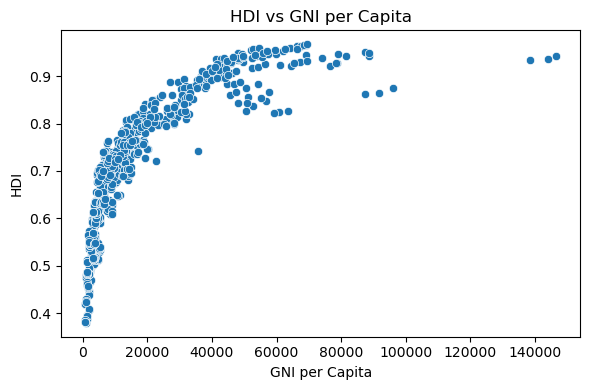

In [52]:

if "gross_inc_percap" in hdi_df.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=hdi_df, x="gross_inc_percap", y="hdi")
    plt.xlabel("GNI per Capita")
    plt.ylabel("HDI")
    plt.title("HDI vs GNI per Capita")
    plt.tight_layout()
    plt.show()



In [58]:

hdi_pivot = hdi_df.pivot(index="country", columns="year", values="hdi").dropna()
hdi_pivot["change_2020_2022"] = hdi_pivot[2022] - hdi_pivot[2020]

print("\n1. Countries with highest HDI improvement (2020–2022):")
print(hdi_pivot["change_2020_2022"].sort_values(ascending=False).head())

print("\n2. Countries with HDI decrease (2020–2022):")
print(hdi_pivot["change_2020_2022"].sort_values().head())

region_mean = hdi_df.groupby("region")["hdi"].mean()

print("\n3. Average HDI by region:")
print(region_mean)

print("\nHighest HDI region:", region_mean.idxmax())
print("Lowest HDI region:", region_mean.idxmin())

print(
    "\n4. Global events impact:\n"
    "COVID-19 disrupted health systems, education, and incomes, "
    "leading to noticeable HDI changes between 2020 and 2022."
)



1. Countries with highest HDI improvement (2020–2022):
country
Andorra       0.041
Azerbaijan    0.038
Ecuador       0.031
Maldives      0.025
Mexico        0.024
Name: change_2020_2022, dtype: float64

2. Countries with HDI decrease (2020–2022):
country
Timor-Leste   -0.067
Ukraine       -0.028
Afghanistan   -0.026
Namibia       -0.024
Lebanon       -0.019
Name: change_2020_2022, dtype: float64

3. Average HDI by region:
region
Middle East    0.788909
South Asia     0.639583
Name: hdi, dtype: float64

Highest HDI region: Middle East
Lowest HDI region: South Asia

4. Global events impact:
COVID-19 disrupted health systems, education, and incomes, leading to noticeable HDI changes between 2020 and 2022.


4.Short Analysis Questions:

In [60]:


# 1. Countries with greatest HDI improvement (2020-2022)
print("\n1. Countries with greatest HDI improvement (2020 to 2022):")

# Get data for 2020 and 2022
hdi_2020 = hdi_problem1b[hdi_problem1b['year'] == 2020][['country', 'hdi']].rename(columns={'hdi': 'hdi_2020'})
hdi_2022 = hdi_problem1b[hdi_problem1b['year'] == 2022][['country', 'hdi']].rename(columns={'hdi': 'hdi_2022'})

# Merge and calculate improvement
improvement_df = pd.merge(hdi_2020, hdi_2022, on='country')
improvement_df['hdi_change'] = improvement_df['hdi_2022'] - improvement_df['hdi_2020']
improvement_df['improvement_pct'] = (improvement_df['hdi_change'] / improvement_df['hdi_2020']) * 100

# Show top 5 improvements
top_improvements = improvement_df.sort_values('hdi_change', ascending=False).head(10)
print("\nTop 10 countries by HDI improvement:")
print(top_improvements[['country', 'hdi_2020', 'hdi_2022', 'hdi_change']].to_string(index=False))

# 2. Countries with HDI decline
print("\n2. Countries with HDI decline (2020 to 2022):")
decline_df = improvement_df[improvement_df['hdi_change'] < 0]
if len(decline_df) > 0:
    print(f"Number of countries with decline: {len(decline_df)}")
    top_declines = decline_df.sort_values('hdi_change').head(10)
    print("\nTop 10 countries by HDI decline:")
    print(top_declines[['country', 'hdi_2020', 'hdi_2022', 'hdi_change']].to_string(index=False))
else:
    print("No countries showed HDI decline from 2020 to 2022")

# 3. Regions with highest and lowest average HDI
print("\n3. Regional HDI analysis:")

# Check if region column exists
if 'region' in hdi_problem1b.columns:
    # Calculate average HDI by region
    region_avg = hdi_problem1b.groupby('region')['hdi'].mean().sort_values(ascending=False)
    
    print(f"\nRegions by average HDI (2020-2022):")
    print(region_avg.to_string())
    
    highest_region = region_avg.idxmax()
    lowest_region = region_avg.idxmin()
    
    print(f"\nHighest average HDI: {highest_region} ({region_avg.max():.3f})")
    print(f"Lowest average HDI: {lowest_region} ({region_avg.min():.3f})")
else:
    print("No 'region' column found. Looking for regional data in country names...")
    # Alternative: group by first letter or continent if available

# 4. COVID-19 impact analysis
print("\n4. Global events impact analysis (e.g., COVID-19):")
print("""
Possible impacts of COVID-19 on HDI (2020-2022):

1. **Health Impact**: 
   - Increased mortality rates could lower life expectancy
   - Healthcare system strain affecting health index

2. **Education Impact**:
   - School closures disrupted education
   - Digital divide widened educational inequalities

3. **Economic Impact**:
   - Economic shutdowns reduced GNI per capita
   - Job losses affected standard of living

4. **Recovery Patterns**:
   - Countries with strong healthcare systems recovered faster
   - Economic stimulus packages helped some countries bounce back
   - Vaccine distribution inequalities created regional disparities
""")


1. Countries with greatest HDI improvement (2020 to 2022):

Top 10 countries by HDI improvement:
   country  hdi_2020  hdi_2022  hdi_change
   Andorra     0.843     0.884       0.041
Azerbaijan     0.722     0.760       0.038
   Ecuador     0.734     0.765       0.031
  Maldives     0.737     0.762       0.025
    Mexico     0.757     0.781       0.024
San Marino     0.844     0.867       0.023
Tajikistan     0.656     0.679       0.023
   Bahamas     0.798     0.820       0.022
    Kuwait     0.826     0.847       0.021
   Türkiye     0.835     0.855       0.020

2. Countries with HDI decline (2020 to 2022):
Number of countries with decline: 54

Top 10 countries by HDI decline:
                         country  hdi_2020  hdi_2022  hdi_change
                     Timor-Leste     0.633     0.566      -0.067
                         Ukraine     0.762     0.734      -0.028
                     Afghanistan     0.488     0.462      -0.026
                         Namibia     0.634     0.61

Problem 2
Advanced HDI Exploration
Objective:
Perform advanced analysis of HDI data, focusing on South Asian countries, composite metrics, outlier detection, metric relationships, and gap analysis.
Tasks:


1 .Create south asian subset :

In [62]:
import pandas as pd

# Load the HDI dataset
df = pd.read_csv("Human_Development_Index_Dataset.csv", encoding="latin1")

# Define South Asian countries
south_asia_countries = [
    "Afghanistan",
    "Bangladesh",
    "Bhutan",
    "India",
    "Maldives",
    "Nepal",
    "Pakistan",
    "Sri Lanka"
]

# Filter dataset for South Asia
south_asia_df = df[df['country'].isin(south_asia_countries)]

# Save the filtered dataset
south_asia_df.to_csv("HDI_SouthAsia.csv", index=False)

print("HDI_SouthAsia.csv file created successfully.")


HDI_SouthAsia.csv file created successfully.


2.	Composite Development Score:

Ranking by Composite Score:
             Composite_Score       hdi
country                               
Maldives         4154.252676  0.682500
Sri Lanka        2502.612949  0.715606
Bhutan           1878.321569  0.634538
Pakistan         1184.282350  0.472545
India            1151.101140  0.541485
Bangladesh       1042.583232  0.531303
Nepal             779.209282  0.504242
Afghanistan       555.454413  0.401030


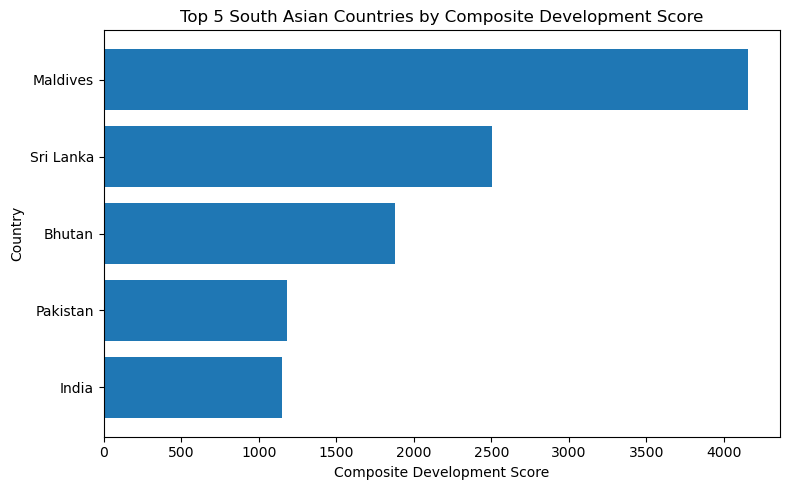

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Load South Asia dataset
south_asia_df = pd.read_csv("HDI_SouthAsia.csv", encoding="latin1")
south_asia_df['Composite_Score'] = (
    0.30 * south_asia_df['life_expectancy'] +
    0.30 * south_asia_df['gross_inc_percap']
)

composite_ranking = south_asia_df.groupby('country')[['Composite_Score', 'hdi']].mean()
composite_ranking = composite_ranking.sort_values(by='Composite_Score', ascending=False)

print("Ranking by Composite Score:")
print(composite_ranking)
top5 = composite_ranking.head(5)

plt.figure(figsize=(8, 5))
plt.barh(top5.index, top5['Composite_Score'])
plt.xlabel('Composite Development Score')
plt.ylabel('Country')
plt.title('Top 5 South Asian Countries by Composite Development Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


3.Outlier Detection:

In [3]:
# =============================================
# TASK 3 & 4: OUTLIER DETECTION & HDI RELATIONSHIPS
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

df = pd.read_csv('Human_Development_Index_Dataset.csv', encoding='latin1')

df.columns = df.columns.str.strip()
latest = df.sort_values('year', ascending=False).groupby('country').first().reset_index()

# Function: detect outliers using IQR
def detect_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return data[(data[col]<lower) | (data[col]>upper)]

# Detect outliers
hdi_out = detect_outliers(latest, 'hdi')
gni_out = detect_outliers(latest, 'gross_inc_percap')

# Label outliers
latest['outlier'] = 'Normal'
latest.loc[latest['country'].isin(hdi_out['country']), 'outlier'] = 'HDI Outlier'
latest.loc[latest['country'].isin(gni_out['country']), 'outlier'] = 'GNI Outlier'
both = set(hdi_out['country']) & set(gni_out['country'])
latest.loc[latest['country'].isin(both), 'outlier'] = 'Both HDI & GNI'

# 2. Scatter plot highlighting outliers
plt.figure(figsize=(8,5))
sns.scatterplot(data=hdi_problem1B, x="gross_inc_percap", y="hdi",
                hue="outlier_label", palette={"Normal":"blue", "Outlier":"red"})
plt.title("Figure 5: Outlier Detection — GNI per Capita vs HDI")
plt.xlabel("Gross National Income (GNI) per Capita")
plt.ylabel("Human Development Index (HDI)")
plt.legend(title="Outlier Status")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# HDI relationships
valid = df.dropna(subset=['hdi','gender_development','life_expectancy'])
corr_gdi = valid['gender_development'].corr(valid['hdi'])
corr_life = valid['life_expectancy'].corr(valid['hdi'])
print(f"Correlation HDI vs Gender Development: {corr_gdi:.3f}")
print(f"Correlation HDI vs Life Expectancy: {corr_life:.3f}")

# Scatter plots with trendlines
fig, axes = plt.subplots(1,2, figsize=(14,6))
for ax, x, xlabel, r in zip(axes,
                             ['gender_development','life_expectancy'],
                             ['Gender Development','Life Expectancy'],
                             [corr_gdi,corr_life]):
    ax.scatter(valid[x], valid['hdi'], alpha=0.6)
    z = np.polyfit(valid[x], valid['hdi'], 1)
    p = np.poly1d(z)
    ax.plot(np.sort(valid[x]), p(np.sort(valid[x])), 'r--', label=f'Trendline (r={r:.2f})')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('HDI')
    ax.set_title(f'{xlabel} vs HDI')
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'Human_Development_Index_Dataset.csv'

4. Gap Analysis:

['Unnamed: 0', 'iso3', 'country', 'year', 'hdi', 'life_expectancy', 'pop_millions', 'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m', 'expec_yr_school', 'expec_yr_school_f', 'expec_yr_school_m', 'mean_yr_school', 'mean_yr_school_f', 'mean_yr_school_m', 'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m', 'gender_development', 'gender_inequality', 'secondary_education_f_%', 'secondary_education_m_%', 'seats_in_parliament_f_%', 'seats_in_parliament_m_%', 'labour_participation_f_%', 'labour_participation_m_%', 'co2_emission_tons', 'mat_footprint_percap_tons']
Top 3 - High GNI but lower HDI:
      country  gross_inc_percap    hdi          gap
14   Maldives       18846.79219  0.762  18846.03019
13   Maldives       16857.60546  0.753  16856.85246
22  Sri Lanka       12958.82226  0.783  12958.03926

Top 3 - Lower GNI but good HDI:
       country  gross_inc_percap    hdi          gap
2  Afghanistan       1335.205733  0.462  1334.743733
1  Afghanistan       1534.135377  0.473  1533.6

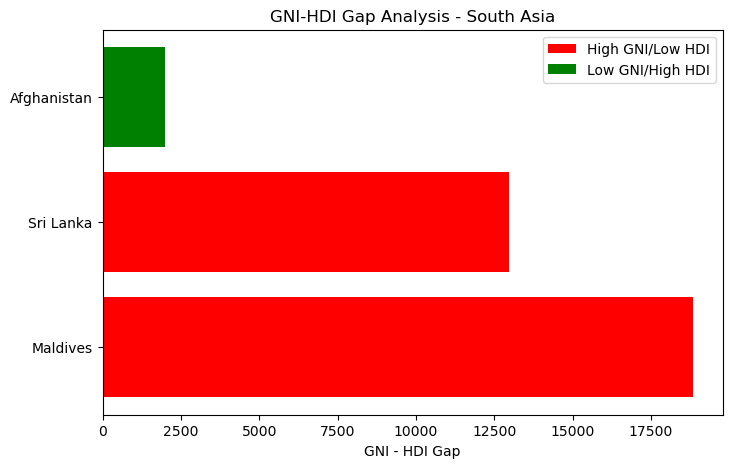

In [96]:

import pandas as pd

south_asia_2022 = pd.read_csv("HDI_SouthAsia_2020_2022.csv", encoding="latin1")

print(south_asia_2022.columns.tolist())

# Find GNI column
gni_col = 'gross_inc_percap' if 'gross_inc_percap' in south_asia_2022.columns else None
if not gni_col:
    for col in south_asia_2022.columns:
        if 'gni' in col.lower() or 'inc' in col.lower():
            gni_col = col
            break

if gni_col:
    # 1. Create gap metric
    south_asia_2022['gap'] = south_asia_2022[gni_col] - south_asia_2022['hdi']
    
    # 2. Show top 3 positive gaps (high GNI, low HDI)
    print("Top 3 - High GNI but lower HDI:")
    top3 = south_asia_2022.nlargest(3, 'gap')[['country', gni_col, 'hdi', 'gap']]
    print(top3)
    
    # 3. Show top 3 negative gaps (low GNI, high HDI)  
    print("\nTop 3 - Lower GNI but good HDI:")
    bottom3 = south_asia_2022.nsmallest(3, 'gap')[['country', gni_col, 'hdi', 'gap']]
    
    print(bottom3)   
    # 4. Simple plot
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(8,5))
    plt.barh(top3['country'], top3['gap'], color='red', label='High GNI/Low HDI')
    plt.barh(bottom3['country'], bottom3['gap'], color='green', label='Low GNI/High HDI')
    plt.xlabel('GNI - HDI Gap')
    plt.title('GNI-HDI Gap Analysis - South Asia')
    plt.legend()
    plt.show()
    
else:
    print("GNI column not found")

Problem 3
Comparative Regional Analysis: South Asia vs Middle East
Objective:
Perform a comparative analysis of HDI and related metrics between South Asia and the Middle East using the 2020–2022 dataset from Problem 1B.
Tasks:


1.	Create Middle East Subset:

In [70]:
import pandas as pd

# Load dataset from Problem 1B
df = pd.read_csv("HDI_problem1B.csv", encoding="latin1")

south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

middle_east_countries = [
    "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
    "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
    "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"
]

df_2020_2022 = df[df['year'].isin([2020, 2021, 2022])]

south_asia_df = df_2020_2022[df_2020_2022['country'].isin(south_asia_countries)]
south_asia_df.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)

middle_east_df = df_2020_2022[df_2020_2022['country'].isin(middle_east_countries)]
middle_east_df.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)

print("Both files created successfully.")


Both files created successfully.


 2.Descriptive Statistics:

In [72]:
# Load saved data
south_asia = pd.read_csv('HDI_SouthAsia_2020_2022.csv')
middle_east = pd.read_csv('HDI_MiddleEast_2020_2022.csv')

# Calculate mean and std for South Asia
sa_mean = south_asia['hdi'].mean()
sa_std = south_asia['hdi'].std()

# Calculate mean and std for Middle East  
me_mean = middle_east['hdi'].mean()
me_std = middle_east['hdi'].std()

print("\nSouth Asia (2020-2022):")
print(f"  Mean HDI: {sa_mean:.3f}")
print(f"  Std Dev:  {sa_std:.3f}")

print("\nMiddle East (2020-2022):")
print(f"  Mean HDI: {me_mean:.3f}")
print(f"  Std Dev:  {me_std:.3f}")

if me_mean > sa_mean:
    diff = me_mean - sa_mean
    print(f"Middle East performs better by {diff:.3f} HDI points")
else:
    diff = sa_mean - me_mean
    print(f"South Asia performs better by {diff:.3f} HDI points")


South Asia (2020-2022):
  Mean HDI: 0.640
  Std Dev:  0.098

Middle East (2020-2022):
  Mean HDI: 0.789
  Std Dev:  0.141
Middle East performs better by 0.149 HDI points


3.Top and Bottom Performers:


South Asia - Top 3:
country
Sri Lanka    0.780
Maldives     0.751
Bhutan       0.678
Name: hdi, dtype: float64

South Asia - Bottom 3:
country
Afghanistan    0.474
Pakistan       0.538
Nepal          0.595
Name: hdi, dtype: float64

Middle East - Top 3:
country
United Arab Emirates    0.933
Israel                  0.911
Bahrain                 0.885
Name: hdi, dtype: float64

Middle East - Bottom 3:
country
Yemen      0.426
Iraq       0.667
Lebanon    0.730
Name: hdi, dtype: float64


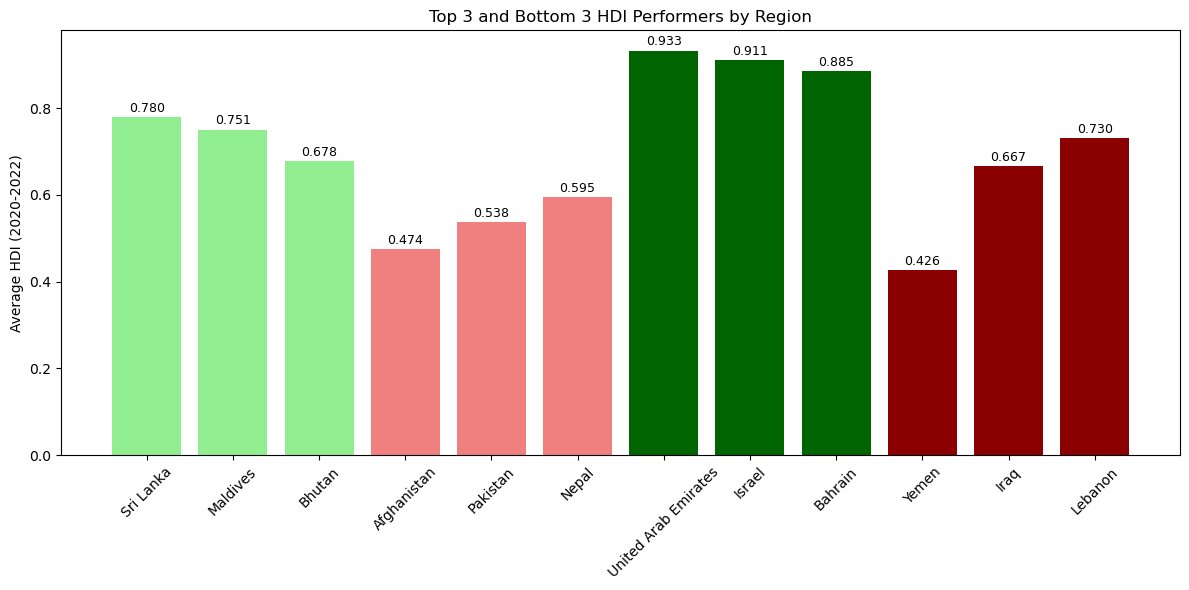

In [74]:
import matplotlib.pyplot as plt

# Get average HDI per country for 2020-2022
sa_avg = south_asia.groupby('country')['hdi'].mean()
me_avg = middle_east.groupby('country')['hdi'].mean()

# Top 3 and bottom 3 for each region
sa_top3 = sa_avg.nlargest(3)
sa_bottom3 = sa_avg.nsmallest(3)

me_top3 = me_avg.nlargest(3)
me_bottom3 = me_avg.nsmallest(3)

print("\nSouth Asia - Top 3:")
print(sa_top3.round(3))
print("\nSouth Asia - Bottom 3:")
print(sa_bottom3.round(3))

print("\nMiddle East - Top 3:")
print(me_top3.round(3))
print("\nMiddle East - Bottom 3:")
print(me_bottom3.round(3))

# Create bar chart
plt.figure(figsize=(12, 6))

# Combine all for plotting
all_countries = pd.concat([sa_top3, sa_bottom3, me_top3, me_bottom3])
colors = []

# Assign colors: top=green, bottom=red, SA=light, ME=dark
for name in all_countries.index:
    if name in sa_top3.index:
        colors.append('lightgreen')
    elif name in sa_bottom3.index:
        colors.append('lightcoral')
    elif name in me_top3.index:
        colors.append('darkgreen')
    else:  # me_bottom3
        colors.append('darkred')

bars = plt.bar(all_countries.index, all_countries.values, color=colors)
plt.ylabel('Average HDI (2020-2022)')
plt.title('Top 3 and Bottom 3 HDI Performers by Region')
plt.xticks(rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

4.	Metric Comparisons:

Using columns:
Gender: gender_development
Life Expectancy: life_expectancy
GNI: gross_inc_percap


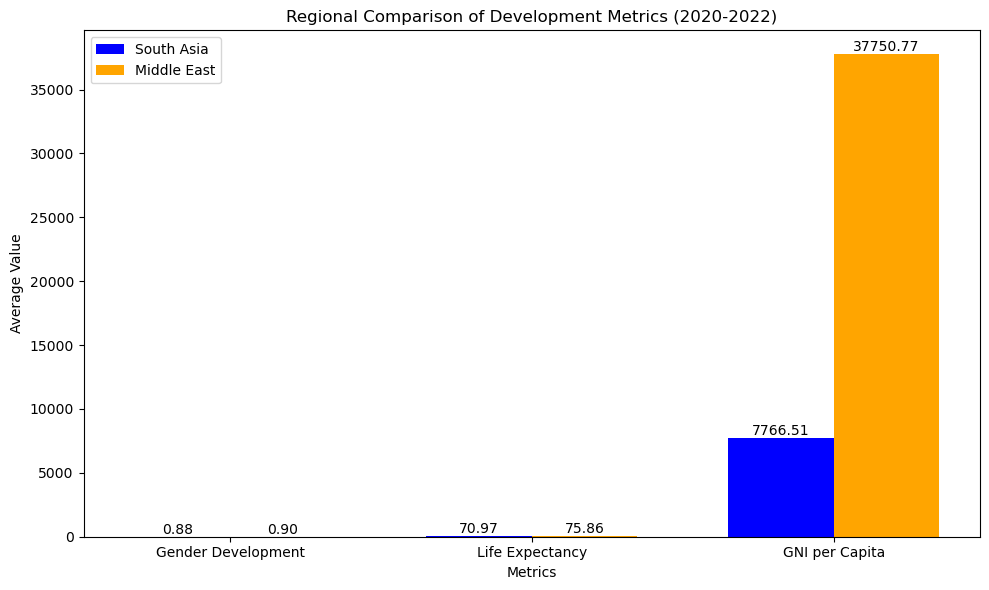

Gender Development:
  South Asia: 0.88, Middle East: 0.90
  Difference: 0.02 (1.7%)

Life Expectancy:
  South Asia: 70.97, Middle East: 75.86
  Difference: 4.89 (6.9%)

GNI per Capita:
  South Asia: 7766.51, Middle East: 37750.77
  Difference: 29984.26 (386.1%)

Greatest disparity: GNI per Capita (29984.26)


In [76]:
# Find column names
# Try to find gender development column
gender_col = None
for col in south_asia.columns:
    if 'gender' in col.lower():
        gender_col = col
        break

# Try to find life expectancy column
life_col = None
for col in south_asia.columns:
    if 'life' in col.lower() and 'expect' in col.lower():
        life_col = col
        break

# Try to find GNI column
gni_col = None
for col in south_asia.columns:
    if 'gni' in col.lower() or 'inc' in col.lower():
        gni_col = col
        break

print("Using columns:")
print(f"Gender: {gender_col}")
print(f"Life Expectancy: {life_col}")
print(f"GNI: {gni_col}")

# Calculate regional averages for each metric
metrics_data = {}

if gender_col:
    metrics_data['Gender Development'] = {
        'South Asia': south_asia[gender_col].mean(),
        'Middle East': middle_east[gender_col].mean()
    }

if life_col:
    metrics_data['Life Expectancy'] = {
        'South Asia': south_asia[life_col].mean(),
        'Middle East': middle_east[life_col].mean()
    }

if gni_col:
    metrics_data['GNI per Capita'] = {
        'South Asia': south_asia[gni_col].mean(),
        'Middle East': middle_east[gni_col].mean()
    }

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

metrics = list(metrics_data.keys())
x = np.arange(len(metrics))
width = 0.35

# Calculate values
sa_values = [metrics_data[m]['South Asia'] for m in metrics]
me_values = [metrics_data[m]['Middle East'] for m in metrics]

bars1 = ax.bar(x - width/2, sa_values, width, label='South Asia', color='blue')
bars2 = ax.bar(x + width/2, me_values, width, label='Middle East', color='orange')

ax.set_xlabel('Metrics')
ax.set_ylabel('Average Value')
ax.set_title('Regional Comparison of Development Metrics (2020-2022)')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=0)
ax.legend()

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height,
                f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

for metric in metrics:
    sa_val = metrics_data[metric]['South Asia']
    me_val = metrics_data[metric]['Middle East']
    disparity = abs(me_val - sa_val)
    disparity_pct = (disparity / min(sa_val, me_val)) * 100
    print(f"{metric}:")
    print(f"  South Asia: {sa_val:.2f}, Middle East: {me_val:.2f}")
    print(f"  Difference: {disparity:.2f} ({disparity_pct:.1f}%)")
    print()

# Identify greatest disparity
if metrics_data:
    disparities = {m: abs(metrics_data[m]['Middle East'] - metrics_data[m]['South Asia']) 
                   for m in metrics}
    max_metric = max(disparities, key=disparities.get)
    print(f"Greatest disparity: {max_metric} ({disparities[max_metric]:.2f})")

5.HDI Disparity:

In [78]:
# Calculate HDI range (max - min)
sa_range = south_asia['hdi'].max() - south_asia['hdi'].min()
me_range = middle_east['hdi'].max() - middle_east['hdi'].min()

# Calculate coefficient of variation (CV = std/mean)
sa_cv = (south_asia['hdi'].std() / south_asia['hdi'].mean()) * 100
me_cv = (middle_east['hdi'].std() / middle_east['hdi'].mean()) * 100

print("\nSouth Asia:")
print(f"  HDI Range: {sa_range:.3f} (Min: {south_asia['hdi'].min():.3f}, Max: {south_asia['hdi'].max():.3f})")
print(f"  Coefficient of Variation: {sa_cv:.1f}%")

print("\nMiddle East:")
print(f"  HDI Range: {me_range:.3f} (Min: {middle_east['hdi'].min():.3f}, Max: {middle_east['hdi'].max():.3f})")
print(f"  Coefficient of Variation: {me_cv:.1f}%")

if sa_cv > me_cv:
    print(f"South Asia has more variation ({sa_cv:.1f}% vs {me_cv:.1f}%)")
else:
    print(f"Middle East has more variation ({me_cv:.1f}% vs {sa_cv:.1f}%)")


South Asia:
  HDI Range: 0.321 (Min: 0.462, Max: 0.783)
  Coefficient of Variation: 15.4%

Middle East:
  HDI Range: 0.513 (Min: 0.424, Max: 0.937)
  Coefficient of Variation: 17.9%
Middle East has more variation (17.9% vs 15.4%)


6.	Correlation Analysis:

Using columns: Gender=gender_inequality, Life=life_expectancy


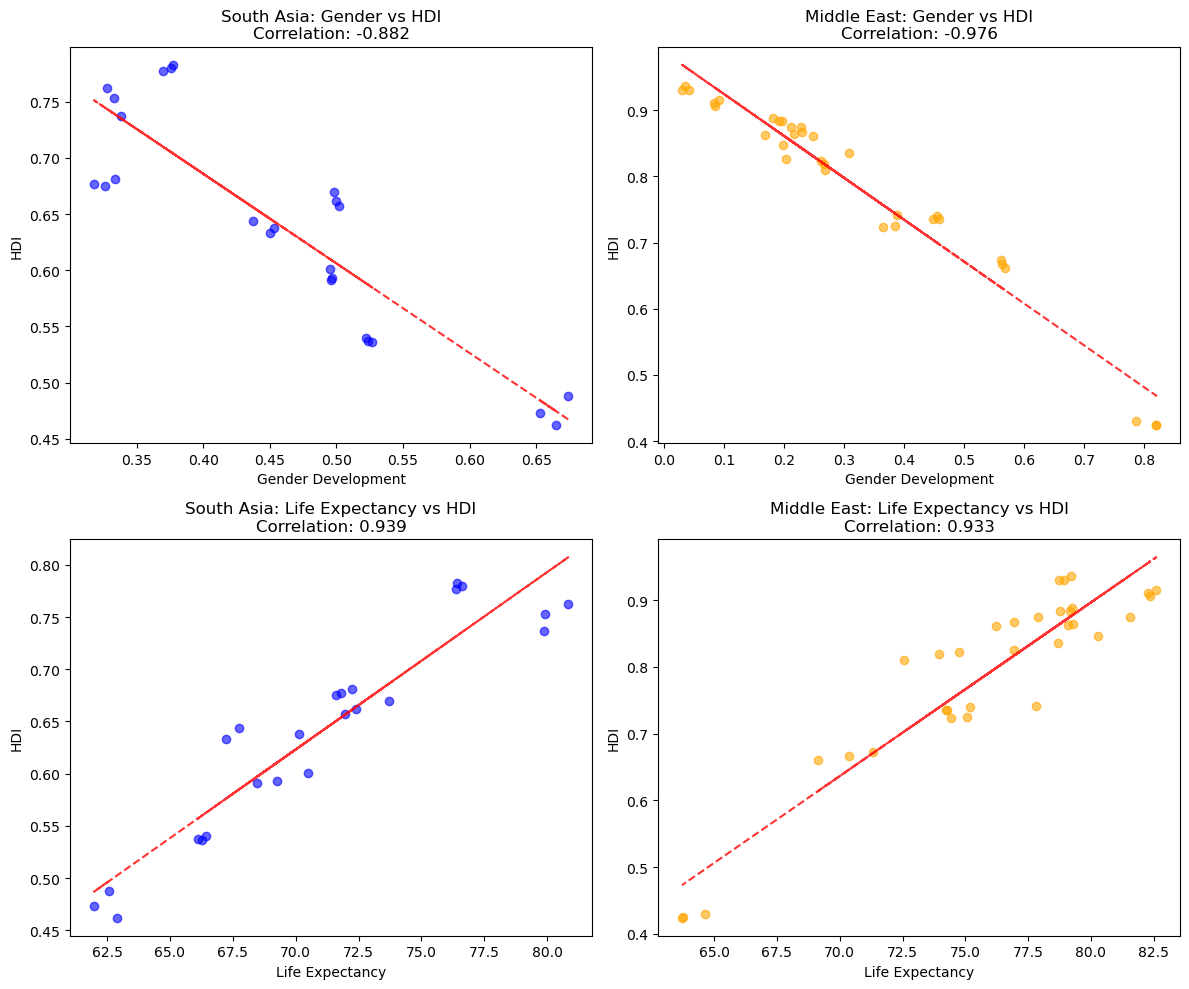

Correlation Interpretation:
1.0 to 0.7: Strong positive
0.7 to 0.3: Moderate positive
0.3 to 0.0: Weak positive
0.0 to -0.3: Weak negative
-0.3 to -0.7: Moderate negative
-0.7 to -1.0: Strong negative


In [80]:
# Find the columns again
gender_col = None
life_col = None

for col in south_asia.columns:
    if 'gender' in col.lower():
        gender_col = col
    if 'life' in col.lower() and 'expect' in col.lower():
        life_col = col

print(f"Using columns: Gender={gender_col}, Life={life_col}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# South Asia correlations
if gender_col:
    # Gender vs HDI - South Asia
    axes[0,0].scatter(south_asia[gender_col], south_asia['hdi'], alpha=0.6, color='blue')
    z = np.polyfit(south_asia[gender_col], south_asia['hdi'], 1)
    p = np.poly1d(z)
    axes[0,0].plot(south_asia[gender_col], p(south_asia[gender_col]), "r--", alpha=0.8)
    corr = south_asia[gender_col].corr(south_asia['hdi'])
    axes[0,0].set_title(f'South Asia: Gender vs HDI\nCorrelation: {corr:.3f}')
    axes[0,0].set_xlabel('Gender Development')
    axes[0,0].set_ylabel('HDI')

# Middle East correlations
if gender_col:
    axes[0,1].scatter(middle_east[gender_col], middle_east['hdi'], alpha=0.6, color='orange')
    z = np.polyfit(middle_east[gender_col], middle_east['hdi'], 1)
    p = np.poly1d(z)
    axes[0,1].plot(middle_east[gender_col], p(middle_east[gender_col]), "r--", alpha=0.8)
    corr = middle_east[gender_col].corr(middle_east['hdi'])
    axes[0,1].set_title(f'Middle East: Gender vs HDI\nCorrelation: {corr:.3f}')
    axes[0,1].set_xlabel('Gender Development')
    axes[0,1].set_ylabel('HDI')

# Life Expectancy vs HDI - South Asia
if life_col:
    axes[1,0].scatter(south_asia[life_col], south_asia['hdi'], alpha=0.6, color='blue')
    z = np.polyfit(south_asia[life_col], south_asia['hdi'], 1)
    p = np.poly1d(z)
    axes[1,0].plot(south_asia[life_col], p(south_asia[life_col]), "r--", alpha=0.8)
    corr = south_asia[life_col].corr(south_asia['hdi'])
    axes[1,0].set_title(f'South Asia: Life Expectancy vs HDI\nCorrelation: {corr:.3f}')
    axes[1,0].set_xlabel('Life Expectancy')
    axes[1,0].set_ylabel('HDI')

# Life Expectancy vs HDI - Middle East
if life_col:
    axes[1,1].scatter(middle_east[life_col], middle_east['hdi'], alpha=0.6, color='orange')
    z = np.polyfit(middle_east[life_col], middle_east['hdi'], 1)
    p = np.poly1d(z)
    axes[1,1].plot(middle_east[life_col], p(middle_east[life_col]), "r--", alpha=0.8)
    corr = middle_east[life_col].corr(middle_east['hdi'])
    axes[1,1].set_title(f'Middle East: Life Expectancy vs HDI\nCorrelation: {corr:.3f}')
    axes[1,1].set_xlabel('Life Expectancy')
    axes[1,1].set_ylabel('HDI')

plt.tight_layout()
plt.show()

print("Correlation Interpretation:")
print("1.0 to 0.7: Strong positive")
print("0.7 to 0.3: Moderate positive")
print("0.3 to 0.0: Weak positive")
print("0.0 to -0.3: Weak negative")
print("-0.3 to -0.7: Moderate negative")
print("-0.7 to -1.0: Strong negative")

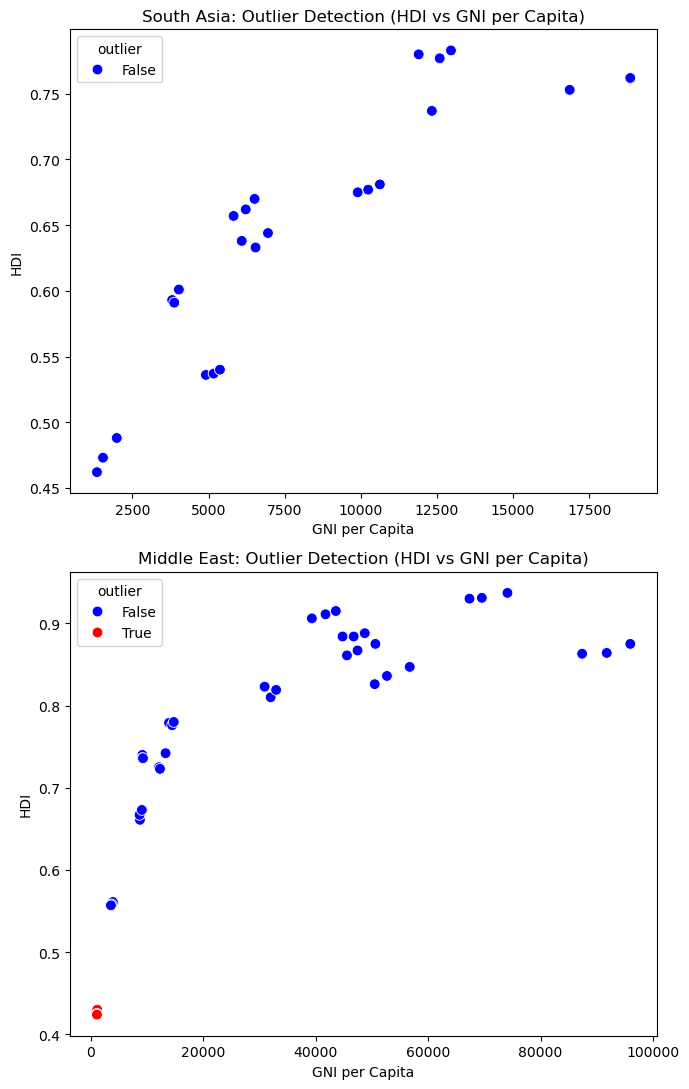

South Asia Outliers: []
Middle East Outliers: ['Yemen']


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load data ---
df = pd.read_csv('Human_Development_Index_Dataset.csv', encoding='latin1')

# --- Define region country lists (no Region column exists in this file) ---
south_asia_list = ['Afghanistan', 'Bangladesh', 'Bhutan', 'India',
                    'Maldives', 'Nepal', 'Pakistan', 'Sri Lanka']

middle_east_list = ['Bahrain', 'Iran (Islamic Republic of)', 'Iraq', 'Israel',
                     'Jordan', 'Kuwait', 'Lebanon', 'Oman', 'Qatar',
                     'Saudi Arabia', 'Syrian Arab Republic',
                     'United Arab Emirates', 'Yemen']

# --- Filter to 2020-2022 and split by region ---
south_asia = df[df['country'].isin(south_asia_list) & df['year'].between(2020, 2022)].copy()
middle_east = df[df['country'].isin(middle_east_list) & df['year'].between(2020, 2022)].copy()

# --- IQR-based outlier detection function ---
def flag_outliers_iqr(data, col='hdi'):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (data[col] < lower) | (data[col] > upper)

south_asia['outlier'] = flag_outliers_iqr(south_asia, 'hdi')
middle_east['outlier'] = flag_outliers_iqr(middle_east, 'hdi')

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(7, 11))
regions = [
    (south_asia, 'South Asia: Outlier Detection (HDI vs GNI per Capita)'),
    (middle_east, 'Middle East: Outlier Detection (HDI vs GNI per Capita)')
]
for ax, (data, title) in zip(axes, regions):
    sns.scatterplot(
        data=data,
        x='gross_inc_percap',
        y='hdi',
        hue='outlier',
        palette={False: 'blue', True: 'red'},
        s=60,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('GNI per Capita')
    ax.set_ylabel('HDI')
    ax.legend(title='outlier')

plt.tight_layout()
plt.show()

# --- Print outlier countries ---
print("South Asia Outliers:", south_asia.loc[south_asia['outlier'], 'country'].unique().tolist())
print("Middle East Outliers:", middle_east.loc[middle_east['outlier'], 'country'].unique().tolist())